# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Merry Shalabi 324007202

Student 2: Samih Warwar 324888155

# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F

# Preprocessing

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 892kB/s] 


Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]


Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.89MB/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



# Encoder Class

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# Decoder Class

In [4]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# Variational Auto Encoder Class

In [5]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device='cpu'):
        super(VAE, self).__init__()
        self.device = device
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(input_dim, hidden_dim, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, logvar

# Loss Function Class


In [6]:
def loss_function(x, x_hat, mean, log_var):
    # avoid log(0) and log(1)
    x_hat = torch.clamp(x_hat, min=1e-7, max=1 - 1e-7)
    loss_reprod = -torch.sum(x * torch.log(x_hat) + (1 - x) * torch.log(1 - x_hat))
    KLD = -0.5 * torch.sum(1 + log_var - mean**2 - torch.exp(log_var))
    return loss_reprod + KLD

# Training Loop

In [12]:
def train(model, optimizer, epochs, device, x_dim=784):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()
        # evaluation step after every 10 epochs
        if (epoch + 1) % 10 == 0:
            plot_reconstruction(model, test_loader, device, x_dim)

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))
    return overall_loss

def plot_reconstruction(model, data_loader, device, x_dim=784):
    model.eval()
    with torch.no_grad():
        # randomly select a batch from the data loader
        x, _ = next(iter(data_loader))

        idx = torch.randint(0, x.shape[0], (1,)).item()
        x = x[idx].view(1, x_dim).to(device)
        x_hat, _, _ = model(x)

        x_hat = x_hat.view(28, 28).cpu().detach().numpy()

        plt.figure(figsize=(2, 2))
        plt.imshow(x_hat, cmap='gray')
        plt.axis('off')
        plt.show()

	Epoch 1 	Average Loss:  186.1364834294136
	Epoch 2 	Average Loss:  166.2080999908702
	Epoch 3 	Average Loss:  162.14974402324185
	Epoch 4 	Average Loss:  159.90642172174978
	Epoch 5 	Average Loss:  158.3443111566152
	Epoch 6 	Average Loss:  157.11688805887417
	Epoch 7 	Average Loss:  156.05184506729967
	Epoch 8 	Average Loss:  155.22502362335663
	Epoch 9 	Average Loss:  154.4855694875574


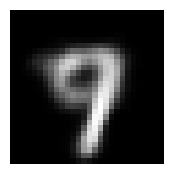

	Epoch 10 	Average Loss:  153.83593397850584
	Epoch 11 	Average Loss:  153.27119908506364
	Epoch 12 	Average Loss:  152.74148968984767
	Epoch 13 	Average Loss:  152.2691538469063
	Epoch 14 	Average Loss:  151.84065682387313
	Epoch 15 	Average Loss:  151.49357134938438
	Epoch 16 	Average Loss:  151.06326882695117
	Epoch 17 	Average Loss:  150.75606583889817
	Epoch 18 	Average Loss:  150.430920104471
	Epoch 19 	Average Loss:  150.1401680535267


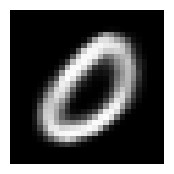

	Epoch 20 	Average Loss:  149.86003415523268
	Epoch 21 	Average Loss:  149.5841795733775
	Epoch 22 	Average Loss:  149.34576916931866
	Epoch 23 	Average Loss:  149.10544952851106
	Epoch 24 	Average Loss:  148.89534628025876
	Epoch 25 	Average Loss:  148.66070080994365
	Epoch 26 	Average Loss:  148.49522601145136
	Epoch 27 	Average Loss:  148.23941184526294
	Epoch 28 	Average Loss:  148.08395514333785
	Epoch 29 	Average Loss:  147.8992119352567


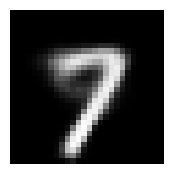

	Epoch 30 	Average Loss:  147.73532581972557
	Epoch 31 	Average Loss:  147.57429180470055
	Epoch 32 	Average Loss:  147.44493754238835
	Epoch 33 	Average Loss:  147.28153100219114
	Epoch 34 	Average Loss:  147.16708857209935
	Epoch 35 	Average Loss:  147.07070113600793
	Epoch 36 	Average Loss:  146.89362555756992
	Epoch 37 	Average Loss:  146.74920381625626
	Epoch 38 	Average Loss:  146.5981989350741
	Epoch 39 	Average Loss:  146.47681048818342


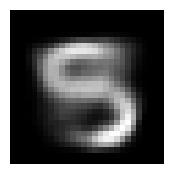

	Epoch 40 	Average Loss:  146.42770529006677
	Epoch 41 	Average Loss:  146.25801377947622
	Epoch 42 	Average Loss:  146.1508848732262
	Epoch 43 	Average Loss:  146.03846966624062
	Epoch 44 	Average Loss:  146.02989689847664
	Epoch 45 	Average Loss:  145.8936661362688
	Epoch 46 	Average Loss:  145.78003042179674
	Epoch 47 	Average Loss:  145.70322131938647
	Epoch 48 	Average Loss:  145.61371939886791
	Epoch 49 	Average Loss:  145.49713418849123


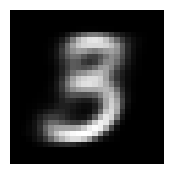

	Epoch 50 	Average Loss:  145.40197585167988


8709578.353515625

In [19]:
latent_dim = 2
model = VAE(latent_dim=latent_dim).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)

train(model, optimizer, epochs=50, device=device)

# Generate and plot digit

In [20]:
def generate_digit(mean_value, var_value):
    latent_dim = model.encoder.fc_mu.out_features
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # get statistics from real encoded data
    with torch.no_grad():
        # get a batch from test set
        x, _ = next(iter(test_loader))
        x = x.view(-1, 784).to(device)
        # encode real data
        mu, logvar = model.encoder(x)
        real_mean = mu.mean(dim=0)
        real_std = torch.exp(0.5 * logvar).mean(dim=0)

    # sample from real latent distribution
    mean = real_mean + mean_value
    var = real_std * var_value

    std = torch.exp(0.5 * var)
    z = mean + std * torch.randn_like(std).to(device)

    with torch.no_grad():
        generated_digit = model.decoder(z).cpu().view(28, 28)

    def plot_digit():
        plt.imshow(generated_digit, cmap="gray")
        plt.axis("off")
        plt.show()

    plot_digit()



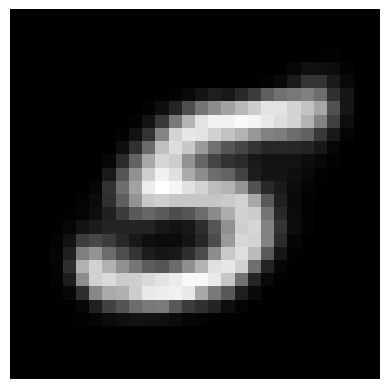

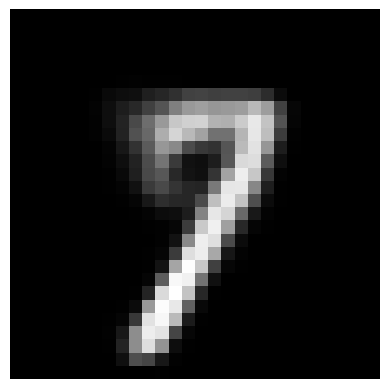

In [29]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)
plt.show()


# Latent Space Grid Visualization

In [30]:
def plot_latent_space(model, scale=1.0, digit_size=28, figsize=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # define the grid size for visualization
    grid_size = 15
    # create a figure to hold the grid of images
    figure = np.zeros((digit_size * grid_size, digit_size * grid_size))

    grid_x = np.linspace(-scale, scale, grid_size)
    grid_y = np.linspace(-scale, scale, grid_size)

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
                # decode the latent vector to generate an image
                x_decoded = model.decoder(z_sample)
                digit = x_decoded.view(digit_size, digit_size).cpu().numpy()
                figure[i * digit_size: (i + 1) * digit_size,
                       j * digit_size: (j + 1) * digit_size] = digit

    # plot the figure
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.show()

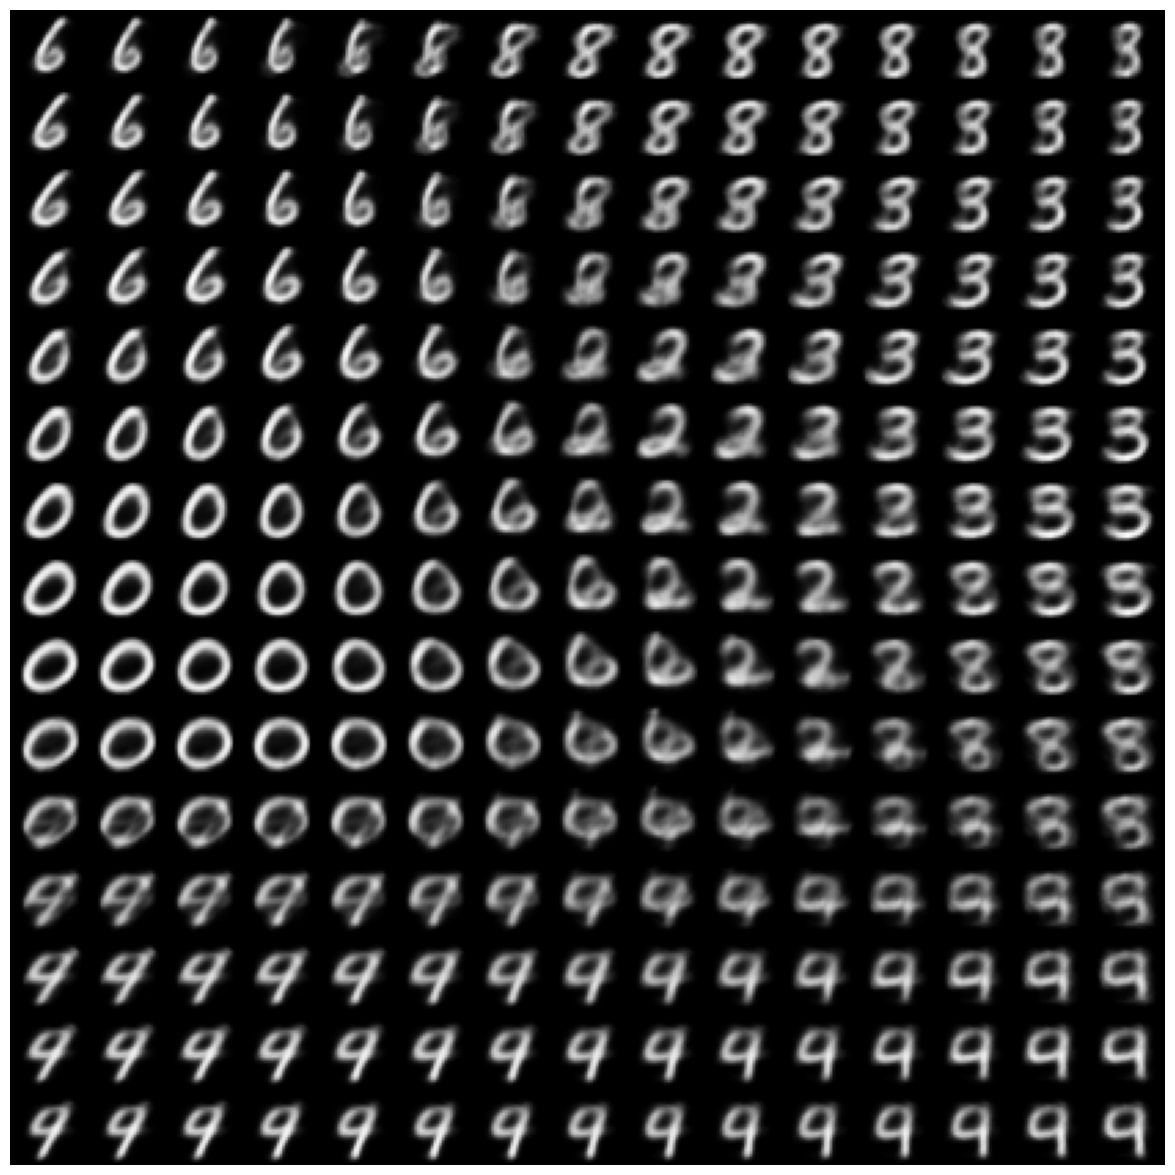

In [ ]:
plot_latent_space(model, scale=1.0)

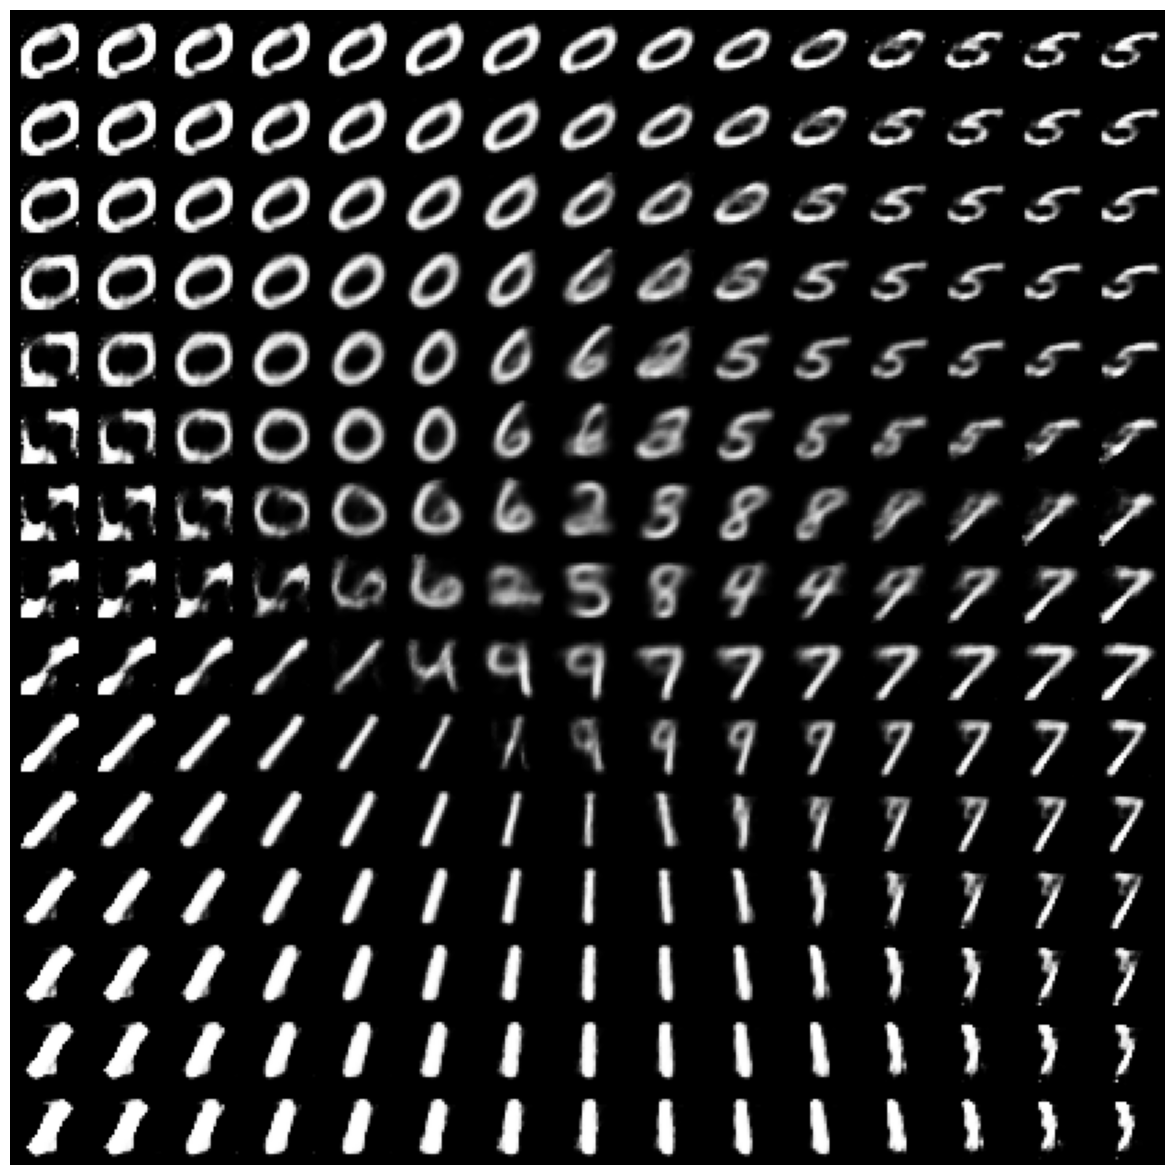

In [31]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

In [34]:

def interpolate_digits(model, dataloader, num_steps=10, digit_size=28, figsize=(10, 2)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    with torch.no_grad():
        x, labels = next(iter(dataloader))
        x = x.view(x.size(0), -1).to(device)
        labels = labels.cpu().numpy()

        # select two digits from different classes
        unique_labels = np.unique(labels)
        digit1_label, digit2_label = np.random.choice(unique_labels, 2, replace=False)

        idx1 = np.where(labels == digit1_label)[0][0]
        idx2 = np.where(labels == digit2_label)[0][0]

        x1, x2 = x[idx1].unsqueeze(0), x[idx2].unsqueeze(0)

        # encode the selected images
        z1_mean, z1_logvar = model.encoder(x1)
        z2_mean, z2_logvar = model.encoder(x2)

        z1 = model.reparameterize(z1_mean, z1_logvar)
        z2 = model.reparameterize(z2_mean, z2_logvar)

        interpolated_images = []

        for t in np.linspace(0, 1, num_steps):
            z_t = (1 - t) * z1 + t * z2
            generated_image = model.decoder(z_t).cpu().view(digit_size, digit_size).numpy()
            interpolated_images.append(generated_image)

    fig, axes = plt.subplots(1, num_steps, figsize=figsize)
    for i, img in enumerate(interpolated_images):
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")

    plt.show()

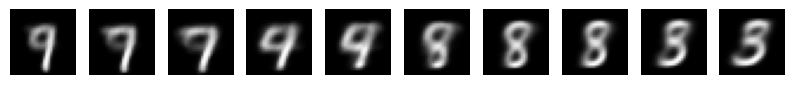

In [35]:
interpolate_digits(model, test_loader, num_steps=10)


In [36]:

from torchsummary import summary

# Print the model summary
print("Model Summary\n")
summary(model, input_size=(784,), device=str(device))


Model Summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 400]         314,000
              ReLU-2                  [-1, 400]               0
            Linear-3                    [-1, 2]             802
            Linear-4                    [-1, 2]             802
           Encoder-5         [[-1, 2], [-1, 2]]               0
            Linear-6                  [-1, 400]           1,200
              ReLU-7                  [-1, 400]               0
            Linear-8                  [-1, 784]         314,384
           Sigmoid-9                  [-1, 784]               0
          Decoder-10                  [-1, 784]               0
Total params: 631,188
Trainable params: 631,188
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 2